# AI-Based Voltage Estimation Tutorial | <font color=red>Part 1</font>: Neural Network-Based LV Voltage Estimation


## 1. Introduction

### What this tutorial does

This tutorial uses **simulated data only**. The goal is to estimate the voltage at 31 simulated LV customer connections from their active power (P) and reactive power (Q).

At each time step:

- **Input:** 62 values: P and Q for each of 31 customers.
- **Output:** 31 estimated voltage magnitudes, one for each customer.

### What you will learn

You will learn how to:

1. load and check the simulated P, Q and voltage data;
2. keep training, validation and test data separate;
3. normalise the data without using future or test information;
4. train a neural network;
5. compare hyperparameters using blocked K-fold validation; and
6. evaluate the selected model once on the held-out test period.

### Notebook layout

- **Section 2:** complete tutorial workflow.
- **Section 3:** exercises that change parts of the workflow.
- **Section 4:** workspace for exercise code.

> **Important:** The test period is used only after the model settings and random seed have been selected. Using test results earlier would make the final accuracy look better than it really is.


## 2. Tutorial

### 2.1 Simulated LV Circuit

This tutorial uses a simulated three-phase, unbalanced residential LV feeder. It represents a typical Victorian network, but it is not a real feeder and contains no real customer measurements.

- There are **31 simulated single-phase customer connections**: 11 on Phase 1, 10 on Phase 2 and 10 on Phase 3.
- Every five minutes, the dataset contains P, Q and voltage values for all 31 customers.
- The neural network receives 62 inputs: `[P1, Q1, P2, Q2, ..., P31, Q31]`.
- It returns 31 voltage estimates: `[V1, V2, ..., V31]`.
- During training, the simulated voltage values are the correct targets.
- After training, the model needs only new P and Q values to estimate voltage.

The model is not given line impedances or network equations directly. Instead, it learns the relationship between P, Q and voltage from examples generated by the fixed simulated feeder. If the feeder layout changes, the model must be checked again and may need new training data.

Upstream MV-voltage variation is not included in Part 1.


<img style="float: middle;" src="LVnetwork-topology.png" width="60%">


**<center>Figure 1. Simulated LV Circuit Topology</center>**


| Simulated customers | Phase allocation | Time interval | NN inputs | NN outputs | Upstream MV input |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 31 | 11 / 10 / 10 | 5 minutes | 62 P/Q values | 31 voltage values | Not used in Part 1 |


**<center>Table 1. Summary of the Simulated LV Voltage-Estimation Problem</center>**


### 2.2 Initialisation

#### 2.2.1 Import libraries

Run this cell first. It imports the packages used for data processing, plotting, neural-network training and error calculation.


In [1]:
from dataclasses import dataclass
from pathlib import Path
import itertools
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 12)


#### 2.2.2 Set the working folder

The working folder is where Jupyter is currently running. The notebook looks in this folder for the simulated dataset, the topology image and the two saved result CSV files.


In [2]:
WORKING_DIRECTORY = Path.cwd()
print(f"Working directory: {WORKING_DIRECTORY.resolve()}")


Working directory: repository root


#### 2.2.3 Set the random seed and device

A random seed helps produce the same initial weights and batch order when the notebook is run again. PyTorch uses a GPU if one is available; otherwise it uses the CPU.


In [3]:
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Computation device: {DEVICE}")


PyTorch version: 2.13.0+cpu
Computation device: cpu


### 2.3 Simulated LV Dataset

#### 2.3.1 Load the training and test data

The simulated data are stored in four files:

- `training/PQ.pkl`: training P and Q inputs;
- `training/V.pkl`: training voltage targets;
- `test/PQ.pkl`: final-test P and Q inputs; and
- `test/V.pkl`: final-test voltage targets.

The training files are used to build and select the model. The test files stay separate until the final evaluation. Blocked K-fold validation divides only the training period; it does not change the supplied train/test split.


In [4]:
DATASET_NAME = "synthentic_data_5_min_LV"

# Support the proposed repository layout and a notebook-local data folder.
data_candidates = [
    WORKING_DIRECTORY / "data" / DATASET_NAME,
    WORKING_DIRECTORY / DATASET_NAME,
    WORKING_DIRECTORY.parent / "data" / DATASET_NAME,
]
DATA_DIRECTORY = next(
    (path for path in data_candidates if path.is_dir()),
    data_candidates[0],
)

TRAIN_DIRECTORY = DATA_DIRECTORY / "training"
TEST_DIRECTORY = DATA_DIRECTORY / "test"
DATA_FILES = {
    "PQ_tr": TRAIN_DIRECTORY / "PQ.pkl",
    "V_tr": TRAIN_DIRECTORY / "V.pkl",
    "PQ_te": TEST_DIRECTORY / "PQ.pkl",
    "V_te": TEST_DIRECTORY / "V.pkl",
}

missing_files = [path for path in DATA_FILES.values() if not path.is_file()]
if missing_files:
    missing_list = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "The LV dataset could not be found. Expected the following files:\n"
        f"{missing_list}\n"
        "Place the included simulated-data folder in one of the documented locations "
        "before continuing."
    )


def load_df_raw(path):
    """Load a pickle file without changing its original values or dtypes."""
    df = pd.read_pickle(path)
    return df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)


PQ_tr_df_raw = load_df_raw(DATA_FILES["PQ_tr"])
V_tr_df_raw = load_df_raw(DATA_FILES["V_tr"])
PQ_te_df_raw = load_df_raw(DATA_FILES["PQ_te"])
V_te_df_raw = load_df_raw(DATA_FILES["V_te"])

print(f"Dataset directory: {DATA_DIRECTORY.resolve()}")
print("The four dataset files were loaded successfully.")

Dataset directory: synthentic_data_5_min_LV
The four dataset files were loaded successfully.


#### 2.3.2 Check the data size

Each P/Q row contains 62 values in this order: `[P1, Q1, P2, Q2, ...]`. Each voltage row contains 31 values.

The expected sizes are:

- training period: 6,048 time steps;
- test period: 2,016 time steps;
- P/Q columns: 62; and
- voltage columns: 31.

The checks below stop the notebook if the files have the wrong shape.


In [5]:
dataset_summary = pd.DataFrame(
    {
        "dataset": ["PQ_tr", "V_tr", "PQ_te", "V_te"],
        "rows": [
            PQ_tr_df_raw.shape[0],
            V_tr_df_raw.shape[0],
            PQ_te_df_raw.shape[0],
            V_te_df_raw.shape[0],
        ],
        "columns": [
            PQ_tr_df_raw.shape[1],
            V_tr_df_raw.shape[1],
            PQ_te_df_raw.shape[1],
            V_te_df_raw.shape[1],
        ],
        "first dtype": [
            str(PQ_tr_df_raw.dtypes.iloc[0]),
            str(V_tr_df_raw.dtypes.iloc[0]),
            str(PQ_te_df_raw.dtypes.iloc[0]),
            str(V_te_df_raw.dtypes.iloc[0]),
        ],
    }
)

display(dataset_summary)

assert len(PQ_tr_df_raw) == len(V_tr_df_raw), (
    "Training P/Q and voltage tables must contain the same number of rows."
)
assert len(PQ_te_df_raw) == len(V_te_df_raw), (
    "Test P/Q and voltage tables must contain the same number of rows."
)
assert PQ_tr_df_raw.shape[1] == PQ_te_df_raw.shape[1] == 62
assert V_tr_df_raw.shape[1] == V_te_df_raw.shape[1] == 31

print(f"Raw PQ_train: {PQ_tr_df_raw.shape}")
print(f"Raw V_train : {V_tr_df_raw.shape}")
print(f"Raw PQ_test : {PQ_te_df_raw.shape}")
print(f"Raw V_test  : {V_te_df_raw.shape}")

print("\nPreview of the first four customer P/Q pairs:")
display(PQ_tr_df_raw.iloc[:5, :8])

print("Preview of the first eight customer voltages:")
display(V_tr_df_raw.iloc[:5, :8])

,dataset,rows,columns,first dtype
0,PQ_tr,6048,62,object
1,V_tr,6048,31,object
2,PQ_te,2016,62,object
3,V_te,2016,31,object


Raw PQ_train: (6048, 62)
Raw V_train : (6048, 31)
Raw PQ_test : (2016, 62)
Raw V_test  : (2016, 31)

Preview of the first four customer P/Q pairs:


,0,1,2,3,4,5,6,7
0,0.120693,0.032818,0.649865,-0.296134,0.349897,0.169386,0.335303,0.051972
1,0.117263,0.028463,0.320885,0.139661,0.215703,0.038703,0.590841,0.254373
2,0.116715,-0.047785,0.822305,0.278458,0.354829,-0.133146,0.882382,-0.27772
3,0.107176,-0.01041,0.990251,-0.436451,0.25331,0.075004,0.230393,-0.026619
4,0.138526,0.01292,1.071487,-0.447064,0.237154,0.051309,0.640064,0.120067


Preview of the first eight customer voltages:


,0,1,2,3,4,5,6,7
0,249.821308,249.888347,249.892601,249.717129,249.83258,249.881812,249.636639,249.76791
1,249.899409,249.843989,249.866556,249.821587,249.771007,249.826385,249.794231,249.713772
2,249.93567,249.821681,249.89114,249.834439,249.801263,249.859837,249.820937,249.751415
3,249.896948,249.884214,249.874603,249.835795,249.858882,249.840205,249.793206,249.802437
4,249.798935,249.826984,249.938723,249.676499,249.803004,249.920977,249.597586,249.742323


#### 2.3.3 Convert and check the data

The code converts all values to `float32`, checks for missing or infinite values and separates the interleaved P/Q columns into individual P and Q arrays.

This confirms that every row has the required **62 inputs and 31 targets** before training starts.


In [6]:
def to_numeric_df(df):
    """Convert every column to a numerical dtype.

    The pickle files are expected to contain numbers, but this conversion
    makes the check explicit for tutorial users.
    """
    return df.apply(pd.to_numeric, errors="coerce")


# Keep the pandas DataFrames for display, then create NumPy arrays for ML.
PQ_tr_df = to_numeric_df(PQ_tr_df_raw)
V_tr_df = to_numeric_df(V_tr_df_raw)
PQ_te_df = to_numeric_df(PQ_te_df_raw)
V_te_df = to_numeric_df(V_te_df_raw)

PQ_tr = PQ_tr_df.to_numpy(np.float32)
V_tr = V_tr_df.to_numpy(np.float32)
PQ_te = PQ_te_df.to_numpy(np.float32)
V_te = V_te_df.to_numpy(np.float32)

# Count invalid values before training. Neural networks cannot learn from NaN
# or infinite values, so the notebook stops here if any are present.
invalid_summary = {
    "PQ_tr": int((~np.isfinite(PQ_tr)).sum()),
    "V_tr": int((~np.isfinite(V_tr)).sum()),
    "PQ_te": int((~np.isfinite(PQ_te)).sum()),
    "V_te": int((~np.isfinite(V_te)).sum()),
}
print("Invalid-value summary:", invalid_summary)
if any(count > 0 for count in invalid_summary.values()):
    raise ValueError(
        "Missing or non-finite values were found after numerical conversion."
    )

# Recover P and Q from P|Q = [P1, Q1, P2, Q2, ...].
# The even-numbered columns are P; the odd-numbered columns are Q.
P_tr, Q_tr = PQ_tr[:, 0::2], PQ_tr[:, 1::2]
P_te, Q_te = PQ_te[:, 0::2], PQ_te[:, 1::2]

C = P_tr.shape[1]
assert Q_tr.shape[1] == C and V_tr.shape[1] == C, (
    "|C| mismatch among P, Q and V in the training period."
)
assert Q_te.shape[1] == C and V_te.shape[1] == C, (
    "|C| mismatch among P, Q and V in the test period."
)
assert PQ_tr.shape[1] == 2 * C and PQ_te.shape[1] == 2 * C

print(f"|C|={C}, |T_train|={P_tr.shape[0]}, |T_test|={P_te.shape[0]}")
print(
    "Shapes -> P_tr", P_tr.shape,
    "Q_tr", Q_tr.shape,
    "V_tr", V_tr.shape,
    "P|Q_tr", PQ_tr.shape,
)

Invalid-value summary: {'PQ_tr': 0, 'V_tr': 0, 'PQ_te': 0, 'V_te': 0}
|C|=31, |T_train|=6048, |T_test|=2016
Shapes -> P_tr (6048, 31) Q_tr (6048, 31) V_tr (6048, 31) P|Q_tr (6048, 62)


#### 2.3.4 Visualise one day of P, Q and V

Before training a neural network, it is useful to inspect the raw simulated time-series data. The training period contains **21 days** and the test period contains **7 days**. Each day has 288 five-minute instances.

Change `DATA_SPLIT_TO_PLOT`, `DAY_TO_PLOT` and `CUSTOMERS_TO_PLOT` in the next cell to explore different days and customers.


In [ ]:
# Choose which part of the dataset to inspect.
# Use "training" for days 1-21, or "test" for days 1-7.
DATA_SPLIT_TO_PLOT = "training"
DAY_TO_PLOT = 1

# Plot a small number of customers so that the figure stays readable.
# Customer numbers are 1-based here because that is easier to read.
CUSTOMERS_TO_PLOT = [1, 16, 31]

# There are 12 five-minute samples per hour and 288 samples per day.
STEPS_PER_DAY = 24 * 60 // 5

plot_sources = {
    "training": {"P": P_tr, "Q": Q_tr, "V": V_tr},
    "test": {"P": P_te, "Q": Q_te, "V": V_te},
}

split_name = DATA_SPLIT_TO_PLOT.lower()
if split_name not in plot_sources:
    raise ValueError("DATA_SPLIT_TO_PLOT must be 'training' or 'test'.")

selected_data = plot_sources[split_name]
available_days = selected_data["P"].shape[0] // STEPS_PER_DAY
if DAY_TO_PLOT < 1 or DAY_TO_PLOT > available_days:
    raise ValueError(
        f"DAY_TO_PLOT must be between 1 and {available_days} for {split_name}."
    )

customer_indices = [customer - 1 for customer in CUSTOMERS_TO_PLOT]
if min(customer_indices) < 0 or max(customer_indices) >= C:
    raise ValueError(f"CUSTOMERS_TO_PLOT must contain customer numbers from 1 to {C}.")

start = (DAY_TO_PLOT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
hours = np.arange(STEPS_PER_DAY) * 5 / 60

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
series_to_plot = [
    ("P", "Active power P"),
    ("Q", "Reactive power Q"),
    ("V", "Voltage V"),
]

for ax, (series_name, title) in zip(axes, series_to_plot):
    matrix = selected_data[series_name]
    for customer_number, customer_index in zip(CUSTOMERS_TO_PLOT, customer_indices):
        ax.plot(
            hours,
            matrix[start:end, customer_index],
            label=f"Customer {customer_number}",
        )
    ax.set_ylabel(series_name)
    ax.set_title(f"{title} on {split_name} day {DAY_TO_PLOT}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()


#### 2.3.5 Make a blocked validation split and normalise the data

The 6,048-step training period is divided into three adjacent blocks of 2,016 steps.

For this short baseline example:

- Block 1 is the validation set.
- Blocks 2 and 3 are the training set.
- The separate 2,016-step test period is not used.

The input and output MinMax scalers learn their minimum and maximum values from the two training blocks only. The same scalers are then applied to the validation block.

A validation value can become smaller than 0 or larger than 1 if it lies outside the range seen in the training blocks. This is expected and does not automatically mean the data are wrong.

Section 2.5.2 repeats this process three times so that each block is used once for validation.


In [9]:
# For the quick baseline, split the 21 training days into three continuous
# blocks of 7 days each. Continuous blocks are used because this is time-series
# data; randomly shuffling individual five-minute points would hide day-to-day
# structure from the validation test.
BASELINE_KFOLDS = 3
baseline_fold_sizes = [len(PQ_tr) // BASELINE_KFOLDS] * BASELINE_KFOLDS
for i in range(len(PQ_tr) % BASELINE_KFOLDS):
    baseline_fold_sizes[i] += 1

# Use the first continuous block for baseline validation.
validation_start = 0
validation_end = baseline_fold_sizes[0]
Xv_raw = PQ_tr[validation_start:validation_end]
Yv_raw = V_tr[validation_start:validation_end]

# Concatenate the remaining two blocks to form the baseline training set.
Xtr_raw = np.concatenate(
    [PQ_tr[:validation_start], PQ_tr[validation_end:]],
    axis=0,
)
Ytr_raw = np.concatenate(
    [V_tr[:validation_start], V_tr[validation_end:]],
    axis=0,
)

# Fit scalers only on the baseline training portion. This prevents validation
# information from leaking into the normalisation step.
xs = MinMaxScaler().fit(Xtr_raw)
ys = MinMaxScaler().fit(Ytr_raw)

Xtr = xs.transform(Xtr_raw).astype(np.float32)
Ytr = ys.transform(Ytr_raw).astype(np.float32)
Xv = xs.transform(Xv_raw).astype(np.float32)
Yv = ys.transform(Yv_raw).astype(np.float32)
Xte = xs.transform(PQ_te).astype(np.float32)

split_summary = pd.DataFrame(
    {
        "matrix": ["Xtr / Ytr", "Xv / Yv", "PQ_te / V_te"],
        "instances": [len(Xtr), len(Xv), len(PQ_te)],
        "role": ["Two baseline training blocks", "One blocked validation fold", "Final test only"],
        "used to fit xs and ys": ["Yes", "No", "No"],
    }
)
display(split_summary)

range_summary = pd.DataFrame(
    {
        "matrix": ["Xtr", "Ytr", "Xv", "Yv"],
        "minimum": [Xtr.min(), Ytr.min(), Xv.min(), Yv.min()],
        "maximum": [Xtr.max(), Ytr.max(), Xv.max(), Yv.max()],
    }
)
display(range_summary.round(4))

print("V_te has not been used or transformed.")

,matrix,instances,role,used to fit xs and ys
0,Xtr / Ytr,4032,Two baseline training blocks,Yes
1,Xv / Yv,2016,One blocked validation fold,No
2,PQ_te / V_te,2016,Final test only,No


,matrix,minimum,maximum
0,Xtr,0.0000,1.0000
1,Ytr,0.0000,1.0000
2,Xv,-0.3668,2.2272
3,Yv,-0.5775,1.0850


V_te has not been used or transformed.


### 2.4 Define the Functions

#### 2.4.1 `NNi`: build the neural network

`NNi` creates a multilayer perceptron:

1. the input layer receives 62 P/Q values;
2. one or more hidden layers learn nonlinear relationships; and
3. the output layer returns 31 voltage estimates.

The number of hidden neurons and activation function can be changed during hyperparameter testing. Weights start from Glorot Uniform values and biases start at zero.


In [10]:
class NNi(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dims=(128,), activation="tanh"):
        super().__init__()

        # Map a text name to a PyTorch activation layer. This makes it easy
        # to compare activations later by changing one hyperparameter.
        acts = {
            "tanh": nn.Tanh,
            "relu": nn.ReLU,
            "sigmoid": nn.Sigmoid,
            "selu": nn.SELU,
            "leaky_relu": nn.LeakyReLU,
            "swish": nn.SiLU,
        }
        if activation not in acts:
            available = ", ".join(acts)
            raise ValueError(
                f"Unknown activation '{activation}'. Choose from: {available}."
            )

        # Build the hidden part of the network, for example 62 -> 93.
        dims = [in_dim] + list(hidden_dims)
        layers = []
        for i in range(len(hidden_dims)):
            layers += [nn.Linear(dims[i], dims[i + 1]), acts[activation]()]

        self.backbone = nn.Sequential(*layers)
        # The final layer maps the hidden representation to 31 voltage values.
        self.out = nn.Linear(hidden_dims[-1], out_dim)

        # Start with balanced random weights and zero biases.
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        # Forward pass used during both training and prediction.
        return self.out(self.backbone(x))

#### 2.4.2 `predict_unscaled`: convert predictions back to volts

The network learns normalised voltage values. This helper makes predictions and uses the fitted output scaler to convert them back to volts. Errors such as RMSE and MAE can then be reported in volts.


In [11]:
def predict_unscaled(model, X_scaled, output_scaler):
    # Estimate voltages and return them in the original voltage scale.
    model.eval()
    with torch.no_grad():
        V_scaled = model(
            torch.from_numpy(X_scaled).to(DEVICE)
        ).cpu().numpy()
    return output_scaler.inverse_transform(V_scaled)


#### 2.4.3 `train_mbgo_adam`: train the baseline model

This function trains a model in small batches using MSE loss, backpropagation and the Adam optimiser.

After each epoch, it checks validation loss. If validation loss stops improving, training ends early and the best saved model is restored. This early-stopping function is used only for the short baseline example.


In [12]:
@dataclass
class TrainResult:
    model: nn.Module
    train_losses: list
    val_losses: list
    best_epoch: int
    best_val: float


def train_mbgo_adam(
    model,
    Xtr,
    Ytr,
    Xv,
    Yv,
    lr=1e-3,
    wd=1e-5,
    batch=72,
    epochs=200,
    patience=25,
):
    """Train an NN with mini-batches, Adam and early stopping."""
    # Pair each normalised P/Q row with its matching normalised voltage row.
    training_data = TensorDataset(
        torch.from_numpy(Xtr),
        torch.from_numpy(Ytr),
    )
    # The DataLoader creates mini-batches and shuffles their order each epoch.
    training_loader = DataLoader(
        training_data,
        batch_size=batch,
        shuffle=True,
    )

    # Keep the validation tensors ready on the selected CPU/GPU device.
    Xv_tensor = torch.from_numpy(Xv).to(DEVICE)
    Yv_tensor = torch.from_numpy(Yv).to(DEVICE)
    model = model.to(DEVICE)

    # MSE is the training objective. Adam updates the weights after each batch.
    loss_fn = nn.MSELoss()
    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=wd,
    )

    train_losses = []
    val_losses = []
    best_val = float("inf")
    best_epoch = 0
    # Store the best validation model so early stopping can restore it later.
    best_state = {
        name: value.detach().clone()
        for name, value in model.state_dict().items()
    }
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_instances = 0

        for X_batch, Y_batch in training_loader:
            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)

            # One gradient-descent step: predict, calculate loss, backpropagate
            # the error, then update the model weights.
            optimiser.zero_grad()
            V_estimated = model(X_batch)
            loss = loss_fn(V_estimated, Y_batch)
            loss.backward()
            optimiser.step()

            total_loss += loss.item() * X_batch.size(0)
            total_instances += X_batch.size(0)

        train_loss = total_loss / total_instances

        # Validation is evaluated without gradient tracking because we do not
        # update model weights on validation data.
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv_tensor), Yv_tensor).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # If validation improves, save the model. Otherwise count one epoch
        # without improvement and stop when patience is reached.
        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_epoch = epoch
            best_state = {
                name: value.detach().clone()
                for name, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    return TrainResult(
        model=model,
        train_losses=train_losses,
        val_losses=val_losses,
        best_epoch=best_epoch,
        best_val=best_val,
    )

#### 2.4.4 Blocked K-fold and fixed-epoch functions

Blocked K-fold validation respects the time order of the data:

1. divide the training period into three adjacent blocks;
2. use one block for validation and the other two for training;
3. fit new scalers using only those two training blocks;
4. train and calculate validation RMSE; and
5. repeat until every block has been used once for validation.

Each hyperparameter setting therefore produces three validation RMSE values. Their average is used to compare settings. The test period is never used in this process.

`run_grid_search` runs all requested hyperparameter combinations and ranks them from the lowest to highest mean validation RMSE.


In [13]:
import itertools
import time

KFOLDS = 3
RUN_FULL_SEARCH = False

SEARCH_SPACE = {
    "hidden_multiplier": [3, 5],
    "activation": ["tanh"],
    "lr": [1e-3, 1e-4],
    "weight_decay": [1e-4, 1e-5],
    "batch_size": [72],
    "epochs": [1000, 2000],
}


def blocked_kfold_indices(n_instances, k=3):
    """Return k consecutive validation blocks and their training indices."""
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    # Keep the original time order and create adjacent validation windows.
    all_indices = np.arange(n_instances)
    folds = []
    start = 0

    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end

    return folds


def train_fixed(model, Xtr, Ytr, lr, wd, batch, epochs):
    """Train for a fixed number of epochs without early stopping."""
    # This helper is used inside the grid search, where every candidate model
    # should train under the same fixed rules.
    dataset = TensorDataset(
        torch.from_numpy(Xtr),
        torch.from_numpy(Ytr),
    )
    loader = DataLoader(dataset, batch_size=batch, shuffle=True)
    model = model.to(DEVICE)
    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=wd,
    )
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)

            # Standard PyTorch training step for one mini-batch.
            optimiser.zero_grad()
            loss = loss_fn(model(X_batch), Y_batch)
            loss.backward()
            optimiser.step()

    return model


def evaluate_config(config, PQ, V, C, k=KFOLDS):
    """Return blocked k-fold RMSE for one hyperparameter configuration."""
    hidden_neurons = round(config["hidden_multiplier"] * C)
    fold_rmse = []
    start_time = time.time()

    for training_indices, validation_indices in blocked_kfold_indices(len(PQ), k):
        # Select one continuous validation block and use the remaining blocks
        # for training this fold.
        PQ_fold_train = PQ[training_indices]
        V_fold_train = V[training_indices]
        PQ_fold_val = PQ[validation_indices]
        V_fold_val = V[validation_indices]

        # Fit fresh scalers inside each fold to avoid validation leakage.
        xs_fold = MinMaxScaler().fit(PQ_fold_train)
        ys_fold = MinMaxScaler().fit(V_fold_train)

        Xt = xs_fold.transform(PQ_fold_train).astype(np.float32)
        Yt = ys_fold.transform(V_fold_train).astype(np.float32)
        Xv_fold = xs_fold.transform(PQ_fold_val).astype(np.float32)

        set_seed(SEED)
        model = NNi(
            in_dim=Xt.shape[1],
            out_dim=Yt.shape[1],
            hidden_dims=(hidden_neurons,),
            activation=config["activation"],
        )
        model = train_fixed(
            model,
            Xt,
            Yt,
            lr=config["lr"],
            wd=config["weight_decay"],
            batch=config["batch_size"],
            epochs=config["epochs"],
        )

        # Convert predictions back to volts before calculating validation RMSE.
        V_fold_estimated = predict_unscaled(model, Xv_fold, ys_fold)
        fold_rmse.append(
            float(np.sqrt(np.mean((V_fold_val - V_fold_estimated) ** 2)))
        )

    return {
        "hidden_neurons": hidden_neurons,
        "RMSE_kfold": float(np.mean(fold_rmse)),
        "RMSE_std": float(np.std(fold_rmse)),
        "train_time_s": float(time.time() - start_time),
    }


def run_grid_search(PQ, V, C, search_space=SEARCH_SPACE):
    """Evaluate every combination and return the configurations ranked by RMSE."""
    # Build every possible combination of the hyperparameter values above.
    configurations = [
        dict(zip(search_space, values))
        for values in itertools.product(*search_space.values())
    ]
    rows = []

    for number, config in enumerate(configurations, start=1):
        scores = evaluate_config(config, PQ, V, C)
        rows.append({**config, **scores})
        print(
            f"Configuration {number:>2}/{len(configurations)}: "
            f"RMSE={scores['RMSE_kfold']:.6f}"
        )

    return (
        pd.DataFrame(rows)
        .sort_values("RMSE_kfold")
        .reset_index(drop=True)
    )

### 2.5 Train and Select the Model

#### 2.5.1 Train a baseline model

The baseline network has the structure `62 → 93 → 31`. It uses `tanh`, Adam, batches of 72 samples and early stopping.

This model is a quick demonstration. Its loss curves show whether the training code works and whether learning is stable. It is **not** used to choose the final hyperparameters.


In [14]:
# Use three hidden neurons per customer for this quick baseline example.
BASELINE_HIDDEN = 3 * C
BASELINE_ACT = "tanh"

# Reset the seed before building the model so the starting weights are repeatable.
set_seed(SEED)
nni = NNi(
    in_dim=Xtr.shape[1],
    out_dim=Ytr.shape[1],
    hidden_dims=(BASELINE_HIDDEN,),
    activation=BASELINE_ACT,
).to(DEVICE)

# Count trainable parameters to show the model size.
trainable_parameters = sum(
    parameter.numel()
    for parameter in nni.parameters()
    if parameter.requires_grad
)

architecture_summary = pd.DataFrame(
    {
        "layer": ["Input", "Hidden", "Output"],
        "dimension": [2 * C, BASELINE_HIDDEN, C],
        "operation": [
            "P|Q",
            f"Linear + {BASELINE_ACT}",
            "Linear V estimate",
        ],
    }
)

display(architecture_summary)
print(nni)
print(f"Trainable parameters: {trainable_parameters:,}")

# Check 2|C| -> |C| before training.
# Four input rows should return four rows of 31 voltage estimates.
sample_input = torch.from_numpy(Xtr[:4]).to(DEVICE)
with torch.no_grad():
    sample_output = nni(sample_input)

assert sample_output.shape == (4, C)
print(f"Interface check: {tuple(sample_input.shape)} -> {tuple(sample_output.shape)}")

,layer,dimension,operation
0,Input,62,P|Q
1,Hidden,93,Linear + tanh
2,Output,31,Linear V estimate


NNi(
  (backbone): Sequential(
    (0): Linear(in_features=62, out_features=93, bias=True)
    (1): Tanh()
  )
  (out): Linear(in_features=93, out_features=31, bias=True)
)
Trainable parameters: 8,773
Interface check: (4, 62) -> (4, 31)


In [15]:
BASELINE_LR = 1e-3
BASELINE_WD = 1e-5
BASELINE_BATCH = 72
BASELINE_EPOCHS = 140
BASELINE_PATIENCE = 25

# Recreate the model so rerunning this cell starts from the same initial state.
set_seed(SEED)
nni = NNi(
    in_dim=Xtr.shape[1],
    out_dim=Ytr.shape[1],
    hidden_dims=(BASELINE_HIDDEN,),
    activation=BASELINE_ACT,
)

baseline_result = train_mbgo_adam(
    nni,
    Xtr,
    Ytr,
    Xv,
    Yv,
    lr=BASELINE_LR,
    wd=BASELINE_WD,
    batch=BASELINE_BATCH,
    epochs=BASELINE_EPOCHS,
    patience=BASELINE_PATIENCE,
)


Vtr_estimated = predict_unscaled(baseline_result.model, Xtr, ys)
Vv_estimated = predict_unscaled(baseline_result.model, Xv, ys)

baseline_metrics = pd.DataFrame(
    {
        "period": ["Training", "Validation"],
        "RMSE (V)": [
            np.sqrt(np.mean((Ytr_raw - Vtr_estimated) ** 2)),
            np.sqrt(np.mean((Yv_raw - Vv_estimated) ** 2)),
        ],
        "MAE (V)": [
            np.mean(np.abs(Ytr_raw - Vtr_estimated)),
            np.mean(np.abs(Yv_raw - Vv_estimated)),
        ],
    }
)

display(baseline_metrics.round(6))
print(f"Epochs completed: {len(baseline_result.train_losses)}")
print(f"Best validation epoch: {baseline_result.best_epoch}")
print(f"Best scaled validation MSE: {baseline_result.best_val:.8f}")


,period,RMSE (V),MAE (V)
0,Training,0.009446,0.006526
1,Validation,0.014651,0.007937


Epochs completed: 140
Best validation epoch: 138
Best scaled validation MSE: 0.00003775


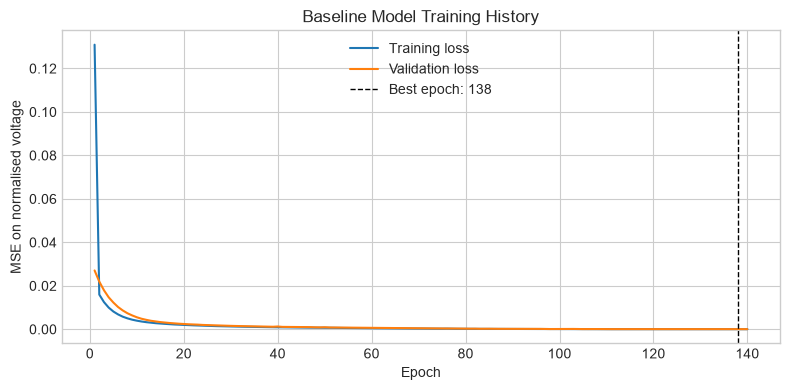

In [16]:
epochs_completed = np.arange(1, len(baseline_result.train_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    epochs_completed,
    baseline_result.train_losses,
    label="Training loss",
)
plt.plot(
    epochs_completed,
    baseline_result.val_losses,
    label="Validation loss",
)
plt.axvline(
    baseline_result.best_epoch,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Best epoch: {baseline_result.best_epoch}",
)
plt.xlabel("Epoch")
plt.ylabel("MSE on normalised voltage")
plt.title("Baseline Model Training History")
plt.legend()
plt.tight_layout()
plt.show()

Training and validation loss should fall at the beginning. If training loss keeps falling while validation loss rises, the model may be overfitting.

RMSE and MAE are calculated after predictions are converted back to volts. Lower values mean more accurate voltage estimates. The formal model-selection process begins in the next section.


#### 2.5.2 Select hyperparameters with blocked K-fold validation

We compare the following settings:

| Hyperparameter | Values tested |
|---|---|
| Hidden neurons | 93 or 155 (3 or 5 times the customer count) |
| Activation | `tanh` |
| Learning rate | `1e-3` or `1e-4` |
| L2 weight decay | `1e-4` or `1e-5` |
| Batch size | 72 |
| Epochs | 1,000 or 2,000 |

This gives `2 × 1 × 2 × 2 × 1 × 2 = 16` settings. Each setting is trained on three folds, so a full search trains 48 models.

Epoch count is one of the settings being compared. For a fair comparison, every candidate runs for exactly 1,000 or 2,000 epochs, so early stopping is not used here.

By default, the notebook loads the completed results from `LV_search_results.csv`. Set `RUN_FULL_SEARCH=True` only when you want to rerun all 48 model fits.


In [17]:
fold_rows = []
for fold_number, (training_indices, validation_indices) in enumerate(
    blocked_kfold_indices(len(PQ_tr), KFOLDS),
    start=1,
):
    fold_rows.append(
        {
            "fold": fold_number,
            "training instances": len(training_indices),
            "validation instances": len(validation_indices),
            "validation range (1-based)": (
                f"{validation_indices[0] + 1}–{validation_indices[-1] + 1}"
            ),
        }
    )

fold_summary = pd.DataFrame(fold_rows)
print("Blocked three-fold partitions inside the 6,048-instance training window:")
display(fold_summary)

if RUN_FULL_SEARCH:
    search_results = run_grid_search(PQ_tr, V_tr, C)
    search_source = "newly calculated results"
else:
    results_path = WORKING_DIRECTORY / "LV_search_results.csv"
    if not results_path.is_file():
        raise FileNotFoundError(
            "LV_search_results.csv was not found beside the notebook. "
            "Upload the complete tutorial folder or set RUN_FULL_SEARCH=True."
        )

    search_results = pd.read_csv(results_path)
    search_source = f"included K-fold results: {results_path.name}"

search_results = (
    search_results
    .sort_values("RMSE_kfold")
    .reset_index(drop=True)
)

columns_to_show = [
    "hidden_neurons",
    "activation",
    "lr",
    "weight_decay",
    "batch_size",
    "epochs",
    "RMSE_kfold",
    "RMSE_std",
]

print(f"Using {search_source}")
print("Complete ranking of all 16 hyperparameter configurations:")
display(search_results[columns_to_show].round(6))

best_row = search_results.iloc[0]
best_config = {
    "hidden_neurons": int(best_row["hidden_neurons"]),
    "activation": str(best_row["activation"]),
    "lr": float(best_row["lr"]),
    "weight_decay": float(best_row["weight_decay"]),
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"]),
}

print("Selected hyperparameters:")
for name, value in best_config.items():
    print(f"  {name}: {value}")
print(f"Mean cross-validation RMSE: {best_row['RMSE_kfold']:.6f} V")


Blocked three-fold partitions inside the 6,048-instance training window:


,fold,training instances,validation instances,validation range (1-based)
0,1,4032,2016,1–2016
1,2,4032,2016,2017–4032
2,3,4032,2016,4033–6048


Using included K-fold results: LV_search_results.csv
Complete ranking of all 16 hyperparameter configurations:


,hidden_neurons,activation,lr,weight_decay,batch_size,epochs,RMSE_kfold,RMSE_std
0,155,tanh,0.0001,0.00001,72,2000,0.010986,0.000593
1,93,tanh,0.0001,0.00001,72,2000,0.011058,0.001003
2,155,tanh,0.0001,0.00001,72,1000,0.011156,0.001125
3,93,tanh,0.0010,0.00001,72,1000,0.011737,0.001098
4,93,tanh,0.0001,0.00001,72,1000,0.011823,0.001172
5,93,tanh,0.0010,0.00001,72,2000,0.012154,0.000426
6,155,tanh,0.0010,0.00001,72,2000,0.012833,0.001006
7,155,tanh,0.0010,0.00001,72,1000,0.013701,0.002051
8,155,tanh,0.0001,0.00010,72,1000,0.055268,0.001336
9,155,tanh,0.0001,0.00010,72,2000,0.055276,0.000914


Selected hyperparameters:
  hidden_neurons: 155
  activation: tanh
  lr: 0.0001
  weight_decay: 1e-05
  batch_size: 72
  epochs: 2000
Mean cross-validation RMSE: 0.010986 V


How to read the K-fold results:

- `RMSE_kfold` is the average validation error across the three folds, measured in volts. Lower is better.
- `RMSE_std` shows how much the RMSE changes between folds. A smaller value means more consistent performance.
- The first row is selected because it has the lowest average RMSE.

The output table contains the complete ranking. The selected settings are used in the next training stage and are also saved in `LV_search_results.csv`.


#### 2.5.3 Compare random seeds and train the final model

The hyperparameters are now fixed. New scalers are fitted using the complete 6,048-step training period.

The same network is then trained ten times with seeds 0 to 9. A different seed changes the starting weights and batch order, so the final error can change slightly. The seed with the lowest training RMSE is selected. Test voltage targets are not used for this choice.

By default, the notebook loads the completed seed comparison from `LV_final_seed_results.csv` and retrains only the selected seed. Set `RUN_MULTI_SEED_TRAINING=True` to rerun all ten training runs.


In [19]:
# Candidate random seeds. Different seeds change the initial weights and the
# order of mini-batches, so this checks whether the final model is stable.
SEEDS_FINAL = list(range(10))
RUN_MULTI_SEED_TRAINING = False

# Refit normalisation using the complete training period only.
# The held-out test period is still not used to fit these scalers.
xs_full = MinMaxScaler().fit(PQ_tr)
ys_full = MinMaxScaler().fit(V_tr)

Xtr_full = xs_full.transform(PQ_tr).astype(np.float32)
Ytr_full = ys_full.transform(V_tr).astype(np.float32)
Xte_full = xs_full.transform(PQ_te).astype(np.float32)


def train_final_seed(seed):
    """Train one final-model candidate and return its training information."""
    # Reset the seed before each candidate so the run is reproducible.
    set_seed(seed)
    model = NNi(
        in_dim=Xtr_full.shape[1],
        out_dim=Ytr_full.shape[1],
        hidden_dims=(best_config["hidden_neurons"],),
        activation=best_config["activation"],
    )

    start_time = time.time()
    model = train_fixed(
        model,
        Xtr_full,
        Ytr_full,
        lr=best_config["lr"],
        wd=best_config["weight_decay"],
        batch=best_config["batch_size"],
        epochs=best_config["epochs"],
    )
    training_time = time.time() - start_time

    Vtr_estimated = predict_unscaled(model, Xtr_full, ys_full)
    train_rmse = float(
        np.sqrt(np.mean((V_tr - Vtr_estimated) ** 2))
    )

    result = {
        "seed": int(seed),
        "train_RMSE": train_rmse,
        "training_time_seconds": float(training_time),
    }
    return model, result

In [20]:
if RUN_MULTI_SEED_TRAINING:
    # Slow path: rerun all candidate seeds from scratch.
    seed_rows = []
    FINAL_MODEL = None
    lowest_train_rmse = float("inf")

    for seed in SEEDS_FINAL:
        candidate_model, seed_result = train_final_seed(seed)
        seed_rows.append(seed_result)
        print(
            f"Seed {seed}: training RMSE "
            f"{seed_result['train_RMSE']:.6f}"
        )

        if seed_result["train_RMSE"] < lowest_train_rmse:
            lowest_train_rmse = seed_result["train_RMSE"]
            FINAL_MODEL = candidate_model
            selected_seed = seed

    final_seed_results = (
        pd.DataFrame(seed_rows)
        .sort_values("train_RMSE")
        .reset_index(drop=True)
    )
    seed_source = "newly trained models"
else:
    seed_results_path = WORKING_DIRECTORY / "LV_final_seed_results.csv"
    if not seed_results_path.is_file():
        raise FileNotFoundError(
            "LV_final_seed_results.csv was not found beside the notebook. "
            "Upload the complete tutorial folder or set RUN_MULTI_SEED_TRAINING=True."
        )

    # Fast path: load the included seed ranking and retrain only the selected
    # seed, which keeps the tutorial practical for a short hands-on session.
    saved_seed_results = pd.read_csv(seed_results_path)
    # Only training information is used for model selection.
    final_seed_results = (
        saved_seed_results[
            ["seed", "train_RMSE", "training_time_seconds"]
        ]
        .sort_values("train_RMSE")
        .reset_index(drop=True)
    )
    selected_seed = int(final_seed_results.iloc[0]["seed"])
    FINAL_MODEL, current_final_run = train_final_seed(selected_seed)
    seed_source = f"included seed ranking: {seed_results_path.name}"

print(f"Using {seed_source}")
display(final_seed_results.round(6))
print(f"Selected seed: {selected_seed}")

if not RUN_MULTI_SEED_TRAINING:
    print(
        "Retrained selected model RMSE: "
        f"{current_final_run['train_RMSE']:.6f}"
    )


Using included seed ranking: LV_final_seed_results.csv


,seed,train_RMSE,training_time_seconds
0,1,0.009299,137.171383
1,9,0.009312,136.519536
2,6,0.009403,136.587838
3,0,0.009420,138.022125
4,5,0.009438,136.515747
5,3,0.009459,136.484250
6,2,0.009670,137.191281
7,7,0.009768,136.649282
8,8,0.009923,136.763636
9,4,0.010060,136.392116


Selected seed: 1
Retrained selected model RMSE: 0.009299


Every candidate uses the same architecture and training settings; only the random seed changes. The seed table is sorted by training RMSE, so the first row is selected.

The selected model and the full-training scalers are kept for the final test. The complete seed comparison remains available in the output table and `LV_final_seed_results.csv`.


### 2.6 Analyse the Final Results

#### 2.6.1 Evaluate the held-out test period

Model selection is complete, so the test period can now be used for the first time.

The selected model estimates all 31 simulated voltage targets. The predictions are converted back to volts and compared with the simulated test targets using:

- **RMSE:** gives more weight to larger errors;
- **MAE:** the average absolute error; and
- **maximum absolute error:** the single largest error.

Lower values are better for all three metrics.


In [22]:
Vte_estimated = predict_unscaled(FINAL_MODEL, Xte_full, ys_full)

test_rmse = float(np.sqrt(mean_squared_error(V_te, Vte_estimated)))
test_mae = float(mean_absolute_error(V_te, Vte_estimated))
test_max_abs_error = float(np.max(np.abs(V_te - Vte_estimated)))

test_metrics = pd.DataFrame(
    {
        "metric": ["Overall RMSE", "Overall MAE", "Maximum absolute error"],
        "value (V)": [test_rmse, test_mae, test_max_abs_error],
    }
)

per_customer_rmse = np.sqrt(
    np.mean((V_te - Vte_estimated) ** 2, axis=0)
)
per_customer_results = (
    pd.DataFrame(
        {
            "customer": np.arange(1, C + 1),
            "RMSE (V)": per_customer_rmse,
        }
    )
    .sort_values("RMSE (V)", ascending=False)
    .reset_index(drop=True)
)

print(f"Selected seed: {selected_seed}")
display(test_metrics.round(6))
print("Customers with the highest test RMSE:")
display(per_customer_results.head(10).round(6))


Selected seed: 1


,metric,value (V)
0,Overall RMSE,0.012346
1,Overall MAE,0.007468
2,Maximum absolute error,0.189606


Customers with the highest test RMSE:


,customer,RMSE (V)
0,24,0.025529
1,23,0.021942
2,26,0.018593
3,19,0.017328
4,22,0.016983
5,29,0.016969
6,14,0.014482
7,8,0.013246
8,30,0.013194
9,27,0.012892


#### 2.6.2 Compare test RMSE for each customer

One overall RMSE can hide customers with larger errors. The next chart calculates a separate test RMSE for each of the 31 simulated customers.


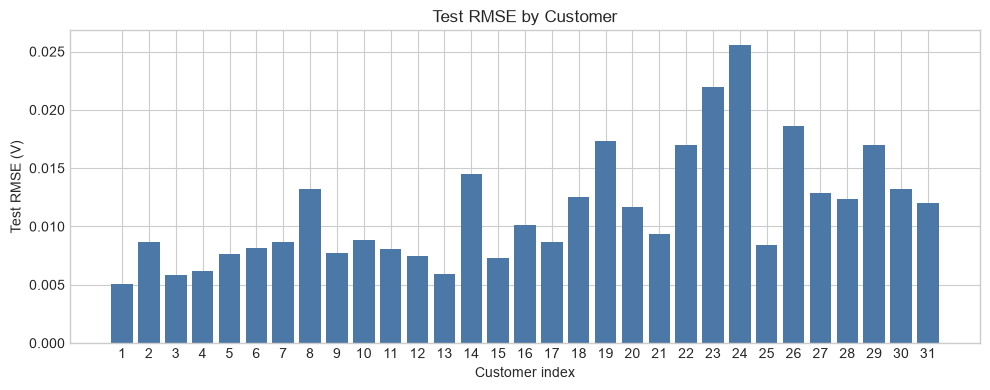

In [23]:
plt.figure(figsize=(10, 4))
plt.bar(np.arange(1, C + 1), per_customer_rmse, color="#4C78A8")
plt.xlabel("Customer index")
plt.ylabel("Test RMSE (V)")
plt.title("Test RMSE by Customer")
plt.xticks(np.arange(1, C + 1))
plt.tight_layout()
plt.show()


#### 2.6.3 Compare simulated target and estimated voltage profiles

Customers are ranked by their individual test RMSE. The plots show the worst, middle and best customers.

Comparing the simulated target with the model estimate helps answer two questions:

1. Does the estimate follow the same time pattern?
2. Are the errors spread across the period or concentrated at a few time steps?


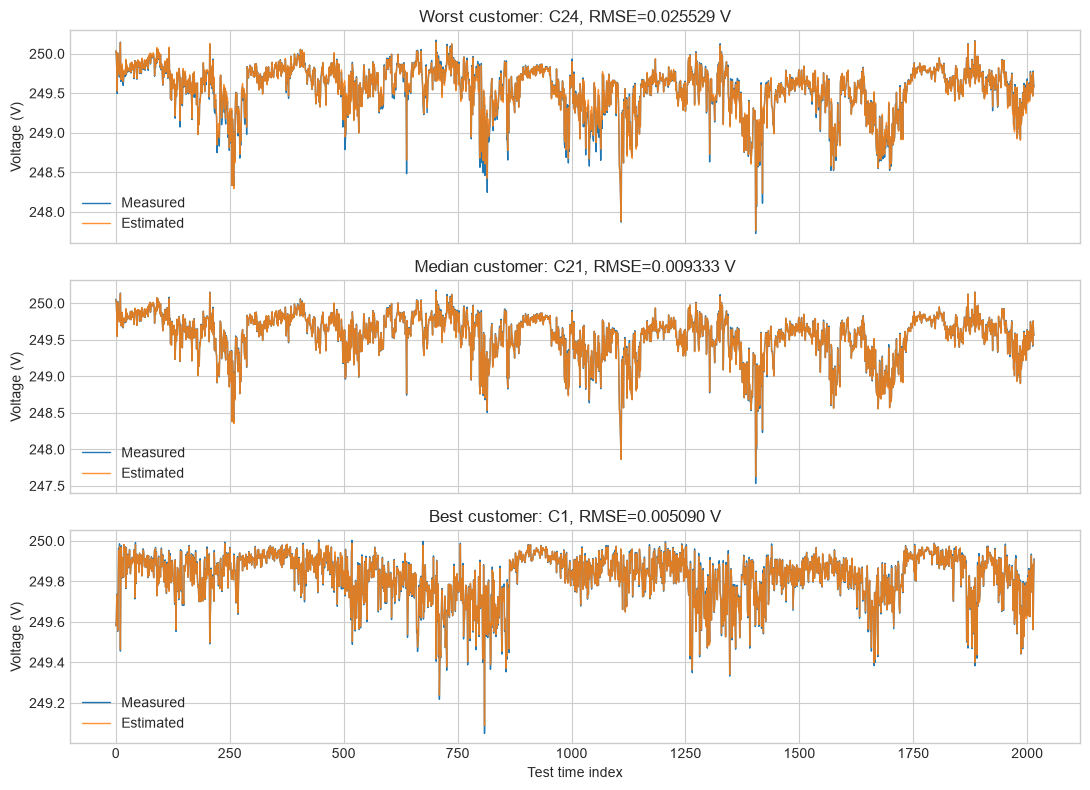

In [24]:
customer_order = np.argsort(per_customer_rmse)
representative_customers = [
    ("Worst", int(customer_order[-1])),
    ("Median", int(customer_order[len(customer_order) // 2])),
    ("Best", int(customer_order[0])),
]
time_index = np.arange(len(V_te))

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for axis, (label, customer) in zip(axes, representative_customers):
    axis.plot(time_index, V_te[:, customer], label="Simulated target", linewidth=1.0)
    axis.plot(
        time_index,
        Vte_estimated[:, customer],
        label="Estimated",
        linewidth=1.0,
        alpha=0.85,
    )
    axis.set_ylabel("Voltage (V)")
    axis.set_title(
        f"{label} customer: C{customer + 1}, "
        f"RMSE={per_customer_rmse[customer]:.6f} V"
    )
    axis.legend(loc="best")
axes[-1].set_xlabel("Test time index")
fig.tight_layout()
plt.show()


In the saved run, seed 1 was selected. The final test RMSE was about **0.01235 V** and the MAE was about **0.00747 V**. Small changes can occur on different hardware or software versions.

These results apply only to this fixed simulated feeder, customer order and test period. They do not prove that the model will have the same accuracy on another feeder or after the network layout changes.


## 3. Exercises

Read all three exercises before starting. Put your exercise code in **Section 4: Simulation Workspace**.

Do not use the held-out test period while choosing hyperparameters or a random seed. Use it once, after all model choices are fixed.


### Exercise: Investigate the LV Voltage-Estimation Model

Use the same simulated LV dataset for all exercises.

**E.1 — Understand the blocked folds**

- Recreate the three adjacent validation blocks.
- Report the time-index range of each validation block.
- Explain why randomly mixing chronological samples could leak information between training and validation.
- Check whether any validation values are outside `[0,1]` after scaling, and explain why this can be normal.

**E.2 — Compare activation functions**

- Compare `tanh` and `relu` with 93 and 155 hidden neurons.
- Keep learning rate `1e-3`, weight decay `1e-5`, batch size 72 and epochs 300.
- Rank the four settings by mean three-fold validation RMSE.
- Do not use the test period.

**E.3 — Train and test the exercise model**

- Take the best setting from E.2.
- Train seeds 0, 1 and 2 using the complete training period.
- Select the seed with the lowest training RMSE.
- Evaluate that model once on the held-out test period.
- Compare its overall test RMSE with the tutorial result.
- Identify the customer with the highest RMSE.
- Decide whether the target and estimated traces show a repeated bias or only a few larger errors.


In [25]:
# Suggested starting point for E.1
# exercise_folds = blocked_kfold_indices(len(PQ_tr), k=3)
# for fold_number, (training_indices, validation_indices) in enumerate(exercise_folds, 1):
#     print(
#         fold_number,
#         len(training_indices),
#         len(validation_indices),
#         validation_indices[0],
#         validation_indices[-1],
#     )


In [26]:
# Suggested starting point for E.2
# EXERCISE_SPACE = {
#     "hidden_multiplier": [3, 5],
#     "activation": ["tanh", "relu"],
#     "lr": [1e-3],
#     "weight_decay": [1e-5],
#     "batch_size": [72],
#     "epochs": [300],
# }
# exercise_results = run_grid_search(
#     PQ_tr,
#     V_tr,
#     C,
#     search_space=EXERCISE_SPACE,
# )
# display(exercise_results.round(6))


For E.3, reuse the full-training scalers and final-training procedure from Section 2.5.3. Use new variable names for the exercise model and results so that the tutorial result remains available for comparison.


## 4. Simulation Workspace

Write and run your exercise code below.


In [27]:
# Assemble and run the code required for Exercises E.1–E.3 here.
